In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
import sys; sys.path.append('/content/gdrive/MyDrive/Colab Notebooks/lib') # add library path

In [3]:
import io
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

from copy import deepcopy as dc
from variable_print import p,ps,pst

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# GridworldEnv Class

## DiscreteEnv Class 생성

In [4]:
from gym import Env, spaces
from gym.utils import seeding

def categorical_sample(prob_n, np_random):
    """ Sample from categorical distribution
        Each row specifies class probabilities """
    prob_n = np.asarray(prob_n)  # prob_n = self.isd
    csprob_n = np.cumsum(prob_n)
    return (csprob_n > np_random.rand()).argmax() # 첫번째 True의 index return

class DiscreteEnv(Env):
    def __init__(self, nS, nA, P, isd):
        self.P = P    # transitions(dict of dicts of lists)
        # P[s][a] == [(probability, nextstate, reward, done), ...]
        self.isd = isd # initial state distribution(list or array)
        self.lastaction=None # for rendering
        self.nS = nS  # number of states
        self.nA = nA  # number of actions
        self.action_space = spaces.Discrete(self.nA)
        self.observation_space = spaces.Discrete(self.nS)

        self.seed()
        self.reset()

    def seed(self, seed=None):
        self.np_random, seed = seeding.np_random(seed)
        return [seed]

    def reset(self):
        self.s = categorical_sample(self.isd, self.np_random)
        self.lastaction=None
        return self.s

    def step(self, a):   # a확률에서 sampling하여 a결정,적용후(s',r,done,p)return
        transitions = self.P[self.s][a] #P[s][a]= [(p,s',r,done), ...], s'에 대한 확률 list
        ns_idx = categorical_sample([t[0] for t in transitions], self.np_random) # sampling, s'결정
        p, ns, r, d= transitions[ns_idx]        # (P[s][a])[s']:(p,s',r,done)
        self.s = ns
        self.lastaction=a
        return (ns, r, d, {"prob" : p})

In [5]:
# action space
UP = 0
RIGHT = 1
DOWN = 2
LEFT = 3

In [6]:
metadata = {'render.modes': ['human', 'ansi']}
class GridworldEnv(DiscreteEnv):
    def __init__(self, shape=[4, 4]): # GrideWorld 초기화: 모든 table생성
        self.shape = shape
        nS = np.prod(shape)     # #states:16 = 4*4, np.prod(): product of elements
        nA = 4                  # #actions
        MAX_Y = shape[0]        # 4
        MAX_X = shape[1]        # 4

        P = {}     #{s:{a:[(p,s',r,T)}}
        grid = np.arange(nS).reshape(shape) # (4,4)
        it = np.nditer(grid, flags=['multi_index']) # state->iterator
        while not it.finished:  ## state_index loop
            s = it.iterindex        # state idx(s)
            y, x = it.multi_index   # state idx(y,x)

            ## P[s][a]=P[s]{a:[(prob, next_state, reward, is_done),...]}=P{s:{a:[(),...]}}
            P[s] = {a: [] for a in range(nA)}  #{s:{a:[]},...}

            def is_done(s): return s == 0 or s == (nS - 1) #Terminal?

            reward = 0.0 if is_done(s) else -1.0           #T면 0,아니면 -1

            if is_done(s): # terminal state면 상태 유지
                P[s][UP] = [(1.0, s, reward, True)]
                P[s][RIGHT] = [(1.0, s, reward, True)]
                P[s][DOWN] = [(1.0, s, reward, True)]
                P[s][LEFT] = [(1.0, s, reward, True)]
            else:          # action별 상태값[(p,s',r,T?)] setting
                ns_up = s if y == 0 else s - MAX_X               # action별로
                ns_right = s if x == (MAX_X - 1) else s + 1      # s'
                ns_down = s if y == (MAX_Y - 1) else s + MAX_X   # 결정 후
                ns_left = s if x == 0 else s - 1                 # action별
                P[s][UP] = [(1.0, ns_up, reward, is_done(ns_up))]# state값 set
                P[s][RIGHT] = [(1.0, ns_right, reward, is_done(ns_right))]
                P[s][DOWN] = [(1.0, ns_down, reward, is_done(ns_down))]
                P[s][LEFT] = [(1.0, ns_left, reward, is_done(ns_left))]
            it.iternext()
        self.P = P   # P{s:{a:[(p,s',r,T?)]}} 현재 class에서 관리하는 table
        self.P_tensor = np.zeros(shape=(nA, nS, nS)) # 상태천이행렬(4,16,16)<-0
        self.R_tensor = np.zeros(shape=(nS, nA))     # 보상(16,4)<-0
        ## P_t/R_t <- P
        for s in self.P.keys():        # P[s] loop
            for a in self.P[s].keys(): # P[s][a] loop
                p_sa, s_prime, r, done = self.P[s][a][0] # <-(p,s',r,T?)
                self.P_tensor[a, s, s_prime] = p_sa      # P_t[a,s,s']<-p
                self.R_tensor[s, a] = r                  # R_t[s,a]<- r
        isd = np.ones(nS) / nS # 상태별 초기 확률을 1/16로 설정
        #상위 class methode사용가능하도록 init 호출
        super(GridworldEnv, self).__init__(nS, nA, P, isd) # P:상위 class에 정보전달

    def observe(self):
        return dc(self.s) #deepcopy

    def render(self, mode='human', close=False):
        """ ==========
            T  o  o  o
            o  x  o  o
            o  o  o  o
            o  o  o  T
            =========="""
        if close: return

        outfile = sys.stdout # io.StringIO()
        grid = np.arange(self.nS).reshape(self.shape)
        it = np.nditer(grid, flags=['multi_index'])

        outfile.write('==' * self.shape[1] + '==\n')

        while not it.finished:
            s = it.iterindex
            y, x = it.multi_index

            if self.s == s:
                output = " x " # current state
            elif s == 0 or s == self.nS - 1:
                output = " T "
            else:
                output = " o "

            if x == 0:
                output = output.lstrip() # removes the specified leading characters
            if x == self.shape[1] - 1:
                output = output.rstrip() # removes the specified trailing characters

            outfile.write(output)

            if x == self.shape[1] - 1:
                outfile.write("\n")
            it.iternext()

        outfile.write('==' * self.shape[1] + '==\n')

# MDP Env 만들기

In [8]:
num_y, num_x = 4, 4

env = GridworldEnv(shape=[num_y, num_x])
observation_space = env.observation_space
action_space = env.action_space

p(env,'env')
p(observation_space,'observation_space')
p(action_space,'action_space')

<<env>>:
Shape:[4, 4]
Type: <class '__main__.GridworldEnv'>
Values: <GridworldEnv instance>
<<observation_space>>:
Shape:()
Type: <class 'gym.spaces.discrete.Discrete'>
Values: Discrete(16)
<<action_space>>:
Shape:()
Type: <class 'gym.spaces.discrete.Discrete'>
Values: Discrete(4)


## Observation space 상태공간 $S$ : 4x4 = 16  
## Action space 행동공간 $A$ : up/right/down/left = 4  

## Transition matrix 상태천이 행렬 $P$ : ($a$, $s$, $s'$) shape(4, 16, 16)    
  **rank-3 Tensor**로 구성 됨
  * Tensor : n차원 자료형 : n개의 axis를 갖는 자료형    
  * $a$ : 0,1,2,3 = [상,우,하,좌]  

### env에서 상태천이 행렬 $P$ 불러오기  
#### env.P[ ] : P table : (p,sn,r,d)정보 저장, 내부에서 관리하는 테이블
#### env.P_tensor : Transition matrix(a,s,s')      


In [9]:
## P table : (p,sn,r,d)정보 저장, 내부에서 관리하는 테이블

#env.P[0] #{s:{a:[(p,sn,r,done)]} }
## {0: [(1.0, 0, 0.0, True)],
##  1: [(1.0, 0, 0.0, True)],
##  2: [(1.0, 0, 0.0, True)],
##  3: [(1.0, 0, 0.0, True)]}

env.P[1] #{s:{a:[(p,sn,r,done)]} } 1번 위치에 대한 정보 들

{0: [(1.0, 1, -1.0, np.False_)],
 1: [(1.0, 2, -1.0, np.False_)],
 2: [(1.0, 5, -1.0, np.False_)],
 3: [(1.0, 0, -1.0, True)]}

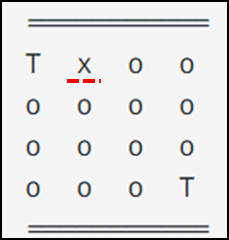

In [10]:
## Transition matrix
Pt = env.P_tensor #(a,s,s')
p(Pt,'P_tensor')

<<P_tensor>>:
Shape:(4, 16, 16)
Type: <class 'numpy.ndarray'>
Values: [[[1. 0. 0. ... 0. 0. 0.]
  [0. 1. 0. ... 0. 0. 0.]
  [0. 0. 1. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 1.]]

 [[1. 0. 0. ... 0. 0. 0.]
  [0. 0. 1. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 1. 0.]
  [0. 0. 0. ... 0. 0. 1.]
  [0. 0. 0. ... 0. 0. 1.]]

 [[1. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 1. 0. 0.]
  [0. 0. 0. ... 0. 1. 0.]
  [0. 0. 0. ... 0. 0. 1.]]

 [[1. 0. 0. ... 0. 0. 0.]
  [1. 0. 0. ... 0. 0. 0.]
  [0. 1. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 1. 0. 0.]
  [0. 0. 0. ... 0. 0. 1.]]]


### up을 선택했을때 s -> s' 전이하는 확률

In [11]:
## up을 선택했을때 s->s' 전이 확률
action_up_prob = Pt[0, :, :]
print(action_up_prob)       # (s, s')

[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


* Action에 대한 이동 확률을 '1'로 설정 : 직관적 이해를 위해 간략화

In [12]:
action_up_prob = Pt[:, 0, :] # S0,모든action,T이므로 제자리
print(action_up_prob)

[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


## Reward : 보상함수 $R$ Rank2 tensor  
* (s,a) = (16,4)  
* 매 이동마다 `-1` 의 보상  

In [13]:
## R tensor
Rt = env.R_tensor #(s,a)
p(Rt,"R")         # Teminal에서 0

<<R>>:
Shape:(16, 4)
Type: <class 'numpy.ndarray'>
Values: [[ 0.  0.  0.  0.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [ 0.  0.  0.  0.]]


## MDP 의 Episode

MDP의 Episode : $<(s_0, a_0, r_0, s_1), (s_1, a_1, r_1, s_2), ..., (s_{t}, a_{t}, r_{t}, s_{t+1}),..., (s_{T-1}, a_{T-1}, r_{T-1}, s_{T})>$ 으로 구성   

* 일반적으로 구현의 편의를 위해 종결 상태를 확인하는 `done` 정보를 episode 튜플에 추가 함   
* `GridworldEnv`에서 에피소드를 한번 시뮬레이션 해보자   

### 시뮬레이션하기 위해서 정책 $\pi$ = 0.25로 고정하고 시작   

In [14]:
s_t0 = env.reset()                          # Gridworld 를 초기화 상태
print(f"State: env.s:{env.s}, s_t0:{s_t0}") # env.s: 현재 상태와 동일

State: env.s:4, s_t0:4


* 직관성을 위해 action index 표시를 바꿔줌   


In [15]:
action_mapper = { 0: 'UP',
                  1: 'RIGHT',
                  2: 'DOWN',
                  3: 'LEFT' }

In [17]:
env.reset()
step_counter = 0

while True: # 정책 4 방향 임의로 선택(pi=0.25)
    print("At t = {}".format(step_counter))
    env.render()                             # current env
    cur_state = env.s                         # current state
    action = np.random.randint(low=0, high=4) # action select(pi=0.25)

    next_state, reward, done, info = env.step(action) #action!

    print(f"\nstate : {cur_state}")
    print(f"aciton : {action_mapper[action]}")
    print(f"reward : {reward}")
    print(f"next state : {next_state}")
#    print(f"info : {info}") # {'prob': 1.0}
    step_counter += 1
    if done: break

At t = 0
T  o  o  o
o  o  x  o
o  o  o  o
o  o  o  T

state : 6
aciton : UP
reward : -1.0
next state : 2
At t = 1
T  o  x  o
o  o  o  o
o  o  o  o
o  o  o  T

state : 2
aciton : UP
reward : -1.0
next state : 2
At t = 2
T  o  x  o
o  o  o  o
o  o  o  o
o  o  o  T

state : 2
aciton : UP
reward : -1.0
next state : 2
At t = 3
T  o  x  o
o  o  o  o
o  o  o  o
o  o  o  T

state : 2
aciton : RIGHT
reward : -1.0
next state : 3
At t = 4
T  o  o  x
o  o  o  o
o  o  o  o
o  o  o  T

state : 3
aciton : RIGHT
reward : -1.0
next state : 3
At t = 5
T  o  o  x
o  o  o  o
o  o  o  o
o  o  o  T

state : 3
aciton : LEFT
reward : -1.0
next state : 2
At t = 6
T  o  x  o
o  o  o  o
o  o  o  o
o  o  o  T

state : 2
aciton : UP
reward : -1.0
next state : 2
At t = 7
T  o  x  o
o  o  o  o
o  o  o  o
o  o  o  T

state : 2
aciton : DOWN
reward : -1.0
next state : 6
At t = 8
T  o  o  o
o  o  x  o
o  o  o  o
o  o  o  T

state : 6
aciton : RIGHT
reward : -1.0
next state : 7
At t = 9
T  o  o  o
o  o  o  x
o  o  o  o


## 여러 에피소드를 시뮬레이션 해보기

* 상태천이 행렬 $P$ : detreministic  
* 정책함수 $\pi$ : stochastic  

In [18]:
def run_episode(env, s0):
    _ = env.reset() # Gridworld 를 초기화합니다.
    env.s = s0
    step_counter = 0
    while True:
        action = np.random.randint(low=0, high=4) # random policy
        next_state, reward, done, info = env.step(action)
        step_counter += 1
        if done: break
    return step_counter

## 10번의 episode 실행
n_episodes = 10
for i in range(n_episodes):
    len_ep = run_episode(env, s0=6)     # 항상 6번에서 시작
    print(f"Episode {i}'s Length: {len_ep}")

Episode 0's Length: 11
Episode 1's Length: 25
Episode 2's Length: 17
Episode 3's Length: 35
Episode 4's Length: 23
Episode 5's Length: 9
Episode 6's Length: 36
Episode 7's Length: 24
Episode 8's Length: 9
Episode 9's Length: 15
